# Multiple Linear Regression
Multiple Linear Regression (MLR) is a statistical method that models the relationship between a single dependent variable and two or more independent variables, allowing for better prediction and understanding of how various factors collectively influence an outcome, unlike simple linear regression which uses only one predictor

In [62]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

#Importing dataset
df = pd.read_csv('/content/Advertising (1).csv') #Importing dataset
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [115]:
#Setting values for x and y
x = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [116]:
print(x.shape)
print(y.shape)

(200, 3)
(200,)


In [117]:
from sklearn.model_selection import train_test_split

# 70% train, 30% temp
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)

# Split temp into validation and test (15% each)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

In [118]:
from sklearn.linear_model import LinearRegression
mlr = LinearRegression()
mlr.fit(x_train, y_train)

LinearRegression()

In [119]:
print("Estimated model slope: ",mlr.intercept_)
print("Estimated model intercept: ")
list(zip(x, mlr.coef_))


Estimated model slope:  2.7089490925159065
Estimated model intercept: 


[('TV', np.float64(0.04405928095746522)),
 ('Radio', np.float64(0.19928749689893954)),
 ('Newspaper', np.float64(0.006882452222275487))]

In [120]:
#Prediciton on validation set
y_valpred_mlr = mlr.predict(x_val)
print("Prediction for validation set: {}".format(y_valpred_mlr))

#Prediciton on test set
y_testpred_mlr = mlr.predict(x_test)
print("Prediction for test set: {}".format(y_testpred_mlr))

Prediction for validation set: [20.91759483  8.91549403  7.60860741  9.76157954  6.52542825 21.73008956
 11.1531472  12.40486324 20.93826535  8.51412012 13.16388427 21.18822792
 13.77469028 21.55107058 14.09330719  4.38190607 20.07590796 21.53501762
 11.66119763  9.01443026 12.49638908 10.29582883 12.15317572 19.76821818
  7.35028523 10.17045434  9.45679576  9.08076637 11.63156862 10.83938827]
Prediction for test set: [16.5653963  13.35556872 14.26202556  5.2243552   8.97026042  6.33636845
 12.77770578  8.69024497 14.30205991 24.25516546  9.28893833 15.71848432
  9.9691939  10.88923816 13.35360735 16.15619251 13.27547079 21.19692502
  9.51332406 22.20231988  8.09081363 18.72473553 18.1011362   7.69519137
  5.6119801   9.4195714  12.00454351 11.80627665 15.12449511 12.17604891]


In [121]:
print("Training set score: {:.4f}".format(mlr.score(x_train, y_train)))
print("Validation set score: {:.4f}".format(mlr.score(x_val, y_val)))
print("Test set score: {:.4f}".format(mlr.score(x_test, y_test)))

Training set score: 0.9055
Validation set score: 0.9145
Test set score: 0.7953


In [122]:
#Calculate RMSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_testpred_mlr)
rmse = np.sqrt(mse)
print("RMSE value: {:.4f}".format(rmse))

RMSE value: 2.2460


In [123]:
#Calculate R2 score
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_testpred_mlr)
print("R2 score value: {:.4f}".format(r2))

R2 score value: 0.7953


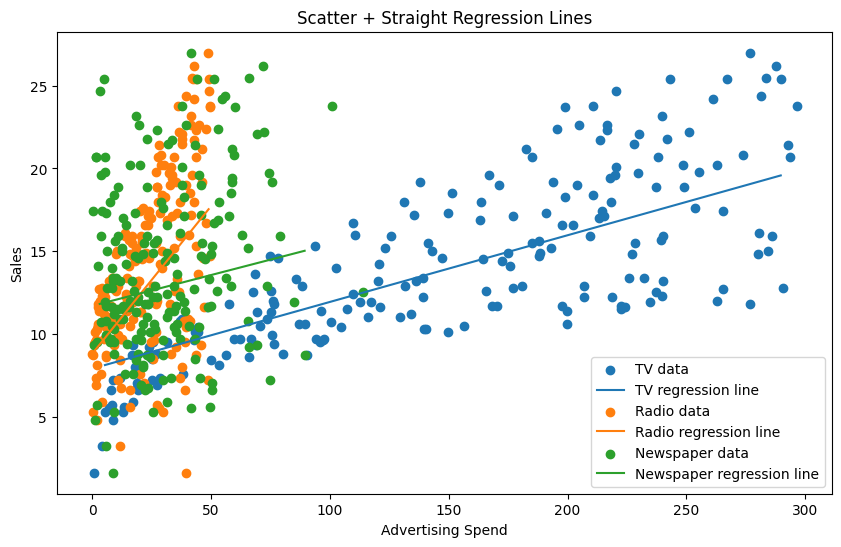

In [128]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
features = ["TV", "Radio", "Newspaper"]

for col in features:
    plt.scatter(x[col], y, label=f"{col} data")
    m, c = np.polyfit(x_test[col], y_testpred_mlr, 1)
    x_line = np.linspace(x_test[col].min(), x_test[col].max(), 100)
    y_line = m * x_line + c
    plt.plot(x_line, y_line, label=f"{col} regression line")

plt.xlabel("Advertising Spend")
plt.ylabel("Sales")
plt.title("Scatter + Straight Regression Lines")
plt.legend()
plt.show()